In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from decimal import ROUND_HALF_UP, Decimal

### Add ExpectedDividend

In [23]:
main_df  = pd.read_csv('input\jpx-tokyo-stock-exchange-prediction\price_features.csv')
main_df ['Date'] = pd.to_datetime(main_df ['Date'])


dividend_df = pd.read_csv('input\jpx-tokyo-stock-exchange-prediction\sub_train_files\stock_prices.csv')
dividend_df['Date'] = pd.to_datetime(dividend_df['Date'])  
dividend_df = dividend_df[['Date', 'SecuritiesCode', 'ExpectedDividend']]


df = pd.merge(main_df, dividend_df, on=['Date', 'SecuritiesCode'], how='left')
df['ExpectedDividend'] = df['ExpectedDividend'].notna().astype('int64')

df.to_csv('input\jpx-tokyo-stock-exchange-prediction\price_features_augment.csv', index=False)

df.head()



,Date,SecuritiesCode,Open,High,Low,Volume,Target,AdjustedClose,Return_5Day,MovingAvg_5Day,...,Volatility_20Day,Return_30Day,MovingAvg_30Day,ExpMovingAvg_30Day,Volatility_30Day,Return_50Day,MovingAvg_50Day,ExpMovingAvg_50Day,Volatility_50Day,ExpectedDividend
0,2017-01-04,1301,2734.0,2755.0,2730.0,31400,0.000730,2742.0,NaN,NaN,...,NaN,NaN,NaN,2742.000000,NaN,NaN,NaN,2742.000000,NaN,0
1,2017-01-05,1301,2743.0,2747.0,2735.0,17900,0.002920,2738.0,NaN,NaN,...,NaN,NaN,NaN,2741.741935,NaN,NaN,NaN,2741.843137,NaN,0
2,2017-01-06,1301,2734.0,2744.0,2720.0,19900,-0.001092,2740.0,NaN,NaN,...,NaN,NaN,NaN,2741.629553,NaN,NaN,NaN,2741.770857,NaN,0
3,2017-01-10,1301,2745.0,2754.0,2735.0,24200,-0.005100,2748.0,NaN,NaN,...,NaN,NaN,NaN,2742.040549,NaN,NaN,NaN,2742.015137,NaN,0
4,2017-01-11,1301,2748.0,2752.0,2737.0,9300,-0.003295,2745.0,NaN,2742.6,...,NaN,NaN,NaN,2742.231481,NaN,NaN,NaN,2742.132191,NaN,0


### Add return_1day

In [21]:
df['return_1day'] = df['AdjustedClose'].pct_change(1)
df.head(5)

C:\Users\mhwu9\AppData\Local\Temp\ipykernel_18584\4234748944.py:1: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df['return_1day'] = df['AdjustedClose'].pct_change(1)


,Date,SecuritiesCode,Open,High,Low,Volume,Target,AdjustedClose,Return_5Day,MovingAvg_5Day,...,MovingAvg_30Day,ExpMovingAvg_30Day,Volatility_30Day,Return_50Day,MovingAvg_50Day,ExpMovingAvg_50Day,Volatility_50Day,ExpectedDividend,AdjustmentFactor,return_1day
0,2017-01-04,1301,2734.0,2755.0,2730.0,31400,0.000730,2742.0,NaN,NaN,...,NaN,2742.000000,NaN,NaN,NaN,2742.000000,NaN,0,1.0,NaN
1,2017-01-05,1301,2743.0,2747.0,2735.0,17900,0.002920,2738.0,NaN,NaN,...,NaN,2741.741935,NaN,NaN,NaN,2741.843137,NaN,0,1.0,-0.001459
2,2017-01-06,1301,2734.0,2744.0,2720.0,19900,-0.001092,2740.0,NaN,NaN,...,NaN,2741.629553,NaN,NaN,NaN,2741.770857,NaN,0,1.0,0.000730
3,2017-01-10,1301,2745.0,2754.0,2735.0,24200,-0.005100,2748.0,NaN,NaN,...,NaN,2742.040549,NaN,NaN,NaN,2742.015137,NaN,0,1.0,0.002920
4,2017-01-11,1301,2748.0,2752.0,2737.0,9300,-0.003295,2745.0,NaN,2742.6,...,NaN,2742.231481,NaN,NaN,NaN,2742.132191,NaN,0,1.0,-0.001092


### Analyze Correlation

Correlation with Target:
SecuritiesCode        0.005953
Open                 -0.009498
High                 -0.009262
Low                  -0.009637
Volume                0.004711
AdjustedClose        -0.013833
Return_5Day           0.001736
MovingAvg_5Day       -0.013645
ExpMovingAvg_5Day    -0.013773
Volatility_5Day       0.013909
Return_10Day         -0.004859
MovingAvg_10Day      -0.013407
ExpMovingAvg_10Day   -0.013665
Volatility_10Day      0.021164
Return_20Day          0.002646
MovingAvg_20Day      -0.013296
ExpMovingAvg_20Day   -0.013515
Volatility_20Day      0.023379
Return_30Day          0.000951
MovingAvg_30Day      -0.012890
ExpMovingAvg_30Day   -0.013369
Volatility_30Day      0.025545
Return_50Day         -0.006615
MovingAvg_50Day      -0.012341
ExpMovingAvg_50Day   -0.013107
Volatility_50Day      0.027009
ExpectedDividend     -0.032486
AdjustmentFactor     -0.001378
return_1day           0.001021
Target                1.000000
Name: Target, dtype: float64


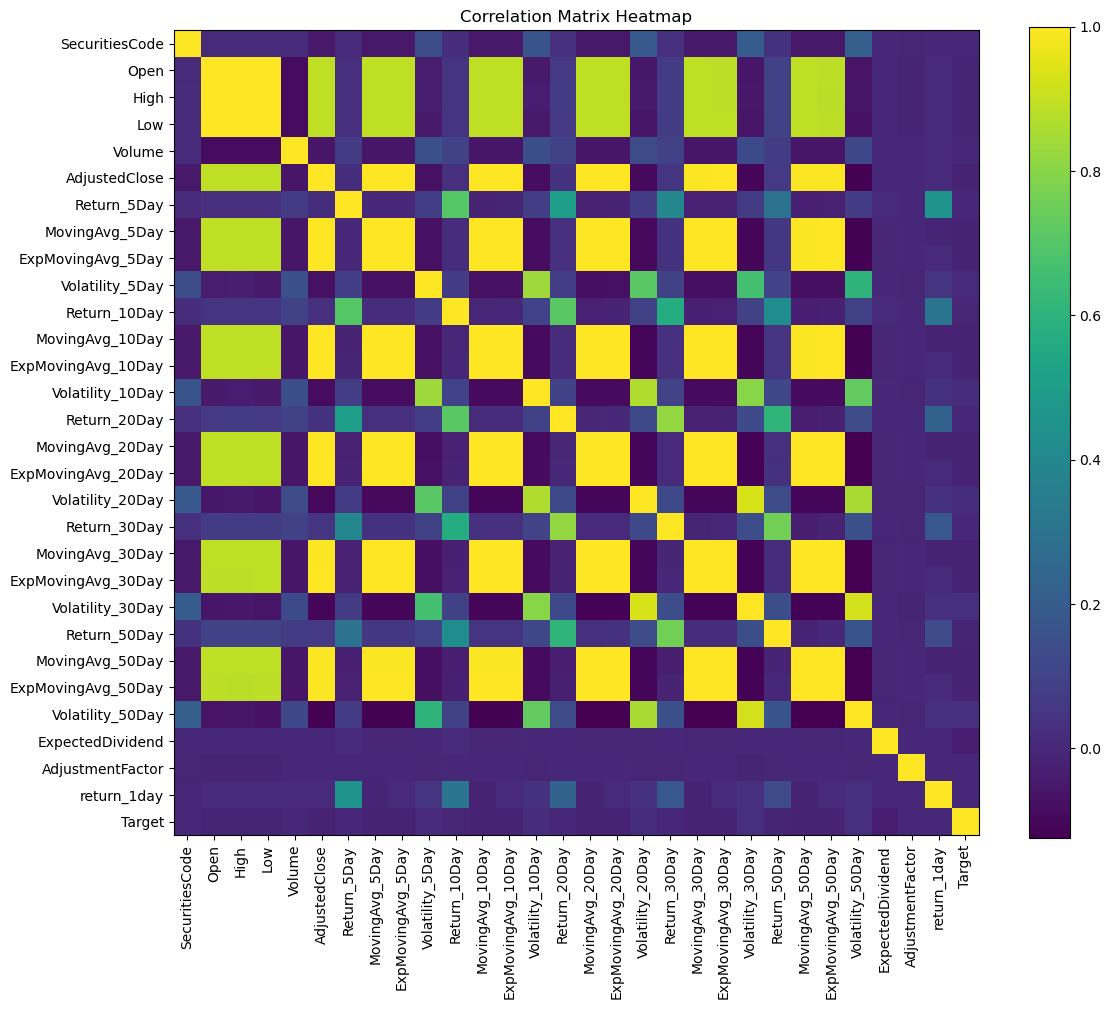

In [22]:
df_numeric = df.select_dtypes(include=['float64', 'int64'])

# Reorder the columns so that "Target" is at the very right (last column)
if "Target" in df_numeric.columns:
    cols = [col for col in df_numeric.columns if col != "Target"] + ["Target"]
    df_numeric = df_numeric[cols]
else:
    print("Warning: 'Target' column not found in numeric columns.")

# Calculate the correlation matrix for all numeric features
corr_matrix = df_numeric.corr()

# Print the correlation between each feature and the Target column
print("Correlation with Target:")
print(corr_matrix['Target'])

# ----------------------------------------
# 1. Visualize the full correlation matrix as a heatmap
# ----------------------------------------
plt.figure(figsize=(12, 10))
plt.imshow(corr_matrix, cmap='viridis', interpolation='none')
plt.colorbar()
plt.xticks(ticks=np.arange(len(corr_matrix.columns)), labels=corr_matrix.columns, rotation=90)
plt.yticks(ticks=np.arange(len(corr_matrix.index)), labels=corr_matrix.index)
plt.title("Correlation Matrix Heatmap")
plt.tight_layout()
plt.show()
